Part A: Understanding the Dataset
Q1. Dataset Overview
Load the dataset and answer the following:
a. How many rows and columns are present?  
b. What are the names of all columns?  
c. Display the first 10 records.
Q2. Data Types and Missing Values
a. Check the data type of each column.  
b. Identify whether any missing values are present.
c. If missing values exist, mention the affected columns.
Q3. Descriptive Statistics Generate summary statistics for all numerical features and answer:
a. Which feature has the highest mean value?
b. Which feature has the highest standard deviation?  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('agriculture_yield_dataset.csv')

# Display first few rows
df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [3]:
#data set overview
print("Number of Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Number of Rows and Columns:
(1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3  

In [4]:
#data type and missing value
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

missing_cols = df.columns[df.isnull().sum() > 0]

print("\nColumns with Missing Values:")
print(missing_cols.tolist())

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with Missing Values:
[]


In [5]:
#descriptive statistics
stats = df.describe()

print(stats)

print("\nFeature with Highest Mean:")
print(stats.loc['mean'].idxmax())

print("\nFeature with Highest Standard Deviation:")
print(stats.loc['std'].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

Part B: Exploratory Data Analysis (EDA)
Q4. Distribution Analysis
Create histograms for:
a. rainfall_mm  
b. temperature_c  
c. fertilizer_kg  
d. yield_ton_per_hectare  
Write 2–3 observations from each histogram.
Q5. Crop Type Analysis
a. Find the number of records for each crop type.  
b. Create a count plot (bar chart) for crop_type.  
c. Which crop appears most frequently?
Q6. Soil Type Analysis
a. Find the frequency of each soil type.  
b. Create a count plot for soil_type.  
c. Which soil type is most common?
Q7. Yield Distribution
Create a histogram of yield_ton_per_hectare.
Answer:
a. Is the distribution approximately normal?  
b. Are there any noticeable outliers?
Q8. Scatter Plot Analysis
a. Create scatter plots of:
1. rainfall_mm vs yield_ton_per_hectare  
2. fertilizer_kg vs yield_ton_per_hectare  
Based on the plots:
b. Which feature appears to have a stronger relationship with yield?
Q9. Correlation Analysis
a. Generate a correlation matrix for numerical features.  b. Create a heatmap.  
c. Identify the top three features most correlated with crop yield.
Q10. Group-Based Analysis
Calculate the average yield for:
a. Each crop type  
b. Each soil type  
c. Which crop and soil type have the highest average yield?

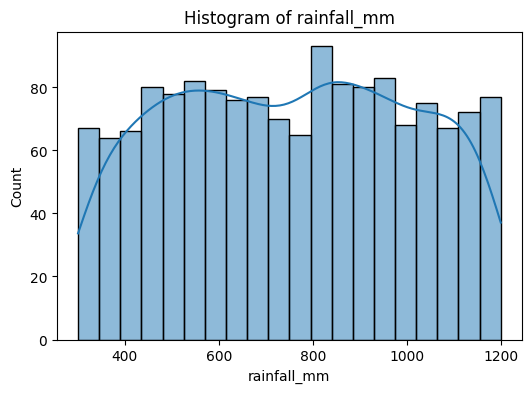

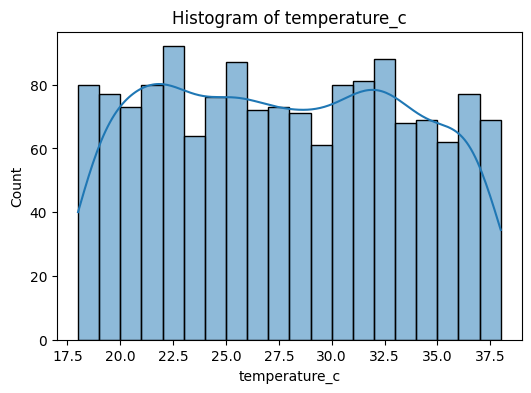

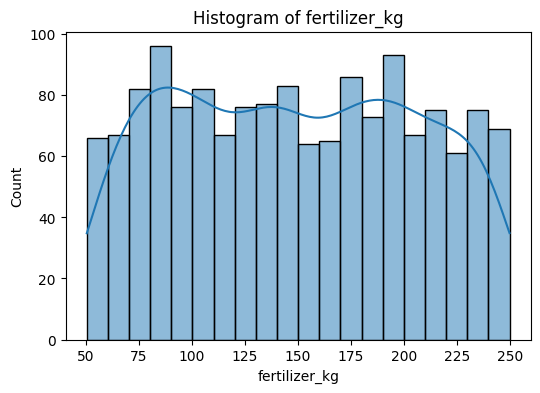

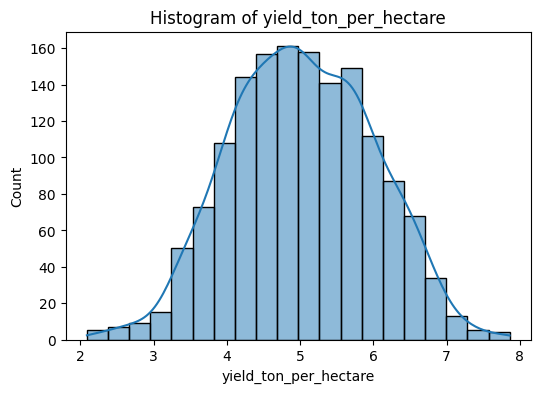

In [6]:
#distribution analysis
cols = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


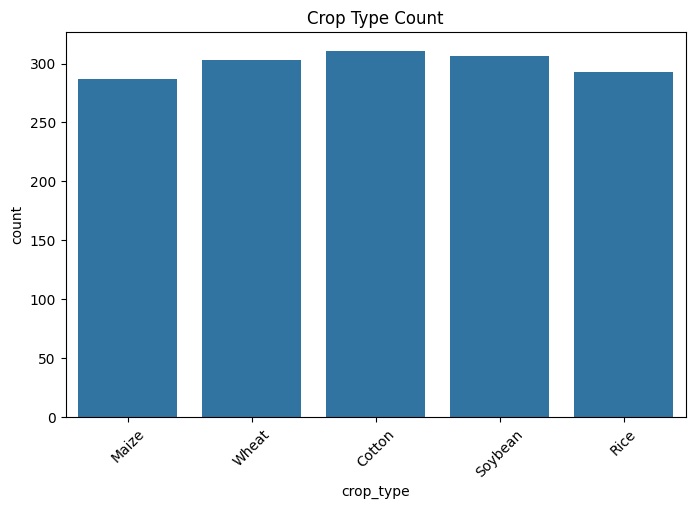

Most Frequent Crop:
Cotton


In [7]:
#crop type analysis
print(df['crop_type'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

print("Most Frequent Crop:")
print(df['crop_type'].mode()[0])

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


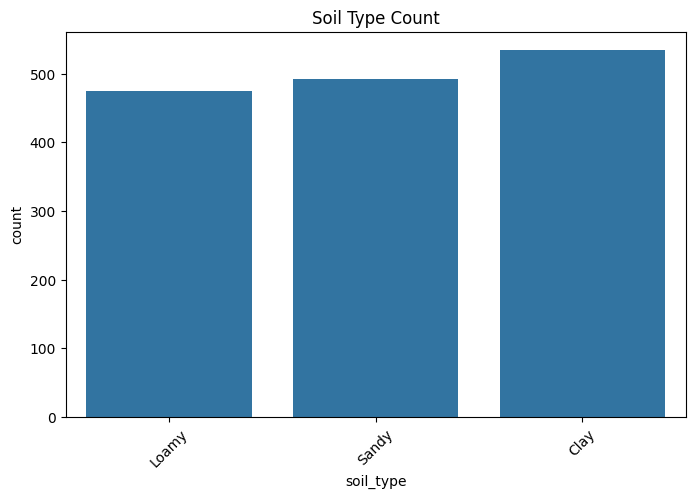

Most Common Soil Type:
Clay


In [8]:
#soil type analysis
print(df['soil_type'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Count")
plt.xticks(rotation=45)
plt.show()

print("Most Common Soil Type:")
print(df['soil_type'].mode()[0])

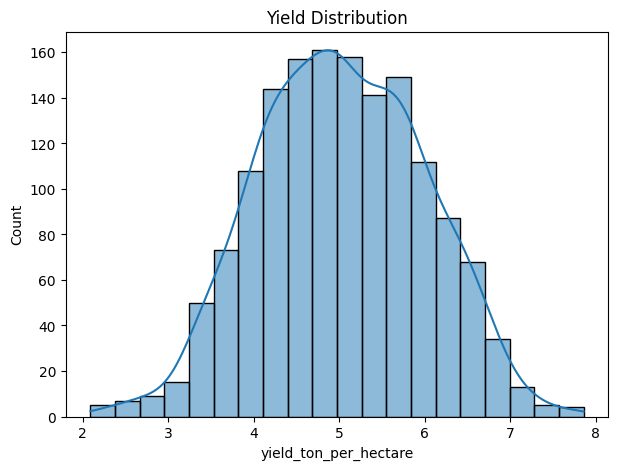

In [9]:
#yeild distribution
plt.figure(figsize=(7,5))
sns.histplot(df['yield_ton_per_hectare'], bins=20, kde=True)
plt.title("Yield Distribution")
plt.show()

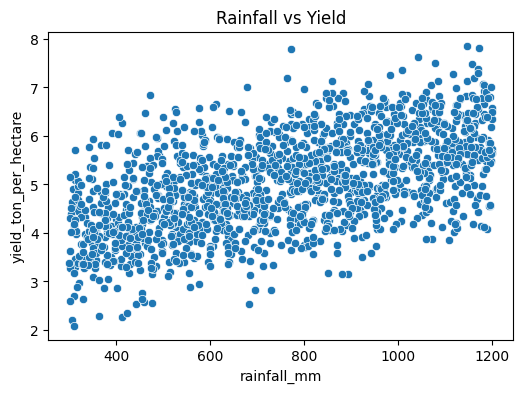

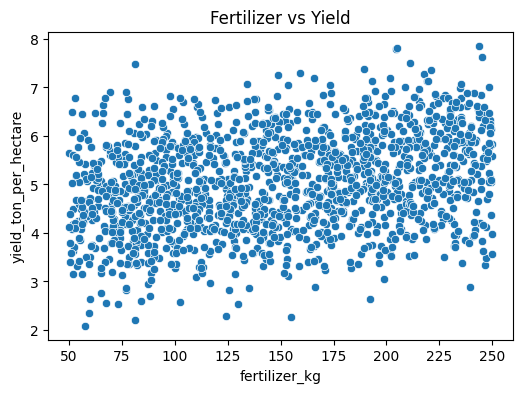

In [10]:
#scatter plot analysis
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Fertilizer vs Yield")
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

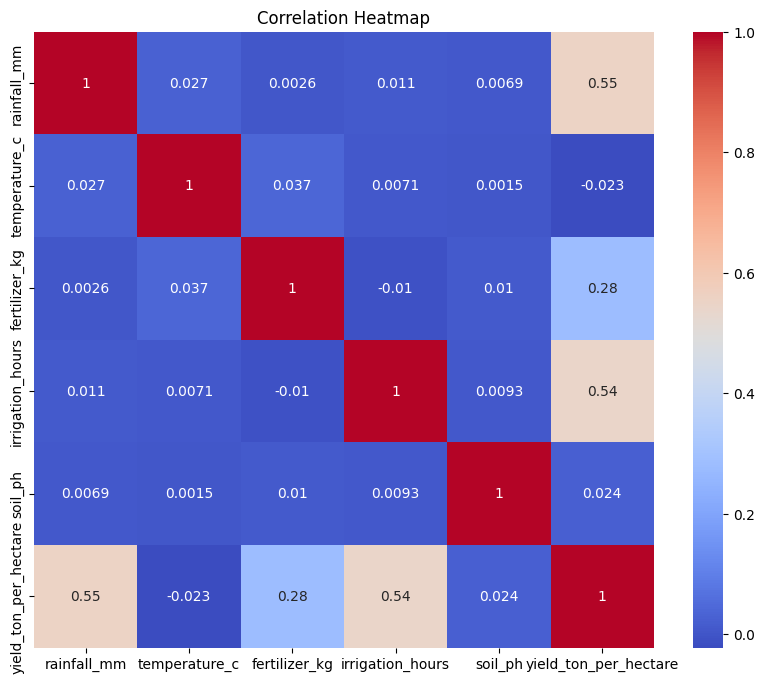


Correlation with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [11]:
#correlation analysis
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

print(corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

yield_corr = corr_matrix['yield_ton_per_hectare'].sort_values(
    ascending=False
)

print("\nCorrelation with Yield:")
print(yield_corr)

In [12]:
#feature with correlated yeild
top3 = yield_corr.drop('yield_ton_per_hectare').head(3)

print("Top 3 Features Correlated with Yield:")
print(top3)

Top 3 Features Correlated with Yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [13]:
#avg yeild by crop type
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print(crop_yield)

print("\nHighest Average Yield Crop:")
print(crop_yield.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Highest Average Yield Crop:
Rice


In [14]:
#avg yeild by soil type
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print(soil_yield)

print("\nHighest Average Yield Soil:")
print(soil_yield.idxmax())

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Average Yield Soil:
Loamy


Part C: Data Preparation
Q11. Feature Encoding
The dataset contains categorical variables.
a. Identify the categorical columns.  
b. Convert them into numerical form using One-Hot Encoding.  
c. Display the first five rows of the transformed dataset.
Q12. Feature Selection
Separate:
a. Input features (X)  
b. Target variable (y)  
c. Specify which column is being used as the target variable.

In [15]:
#feature encoding
cat_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(cat_cols.tolist())

Categorical Columns:
['crop_type', 'soil_type']


In [16]:
#one hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat  soil_type_Loamy  soil_type_Sandy  
0            

In [17]:
#feature selection
target = 'yield_ton_per_hectare'

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

print("Target Variable:")
print(target)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Target Variable:
yield_ton_per_hectare
X Shape: (1500, 11)
y Shape: (1500,)


Part D: Machine Learning
Q13. Train-Test Split
Split the dataset into:
a. 80% Training Data  
b. 20% Testing Data  
c. Display the shape of:
 X_train  
 X_test  
 y_train  
 y_test  
Q14. Linear Regression Model
a.Train a Linear Regression model.  
b.Display the model coefficients and intercept.  
c.Which feature has the highest positive coefficient?

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (1200, 11)
X_test Shape : (300, 11)
y_train Shape: (1200,)
y_test Shape : (300,)


In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nCoefficients:")
print(coef_df)

Intercept:
1.587132027736121

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933


In [20]:
highest_feature = coef_df.loc[
    coef_df['Coefficient'].idxmax()
]

print("\nFeature with Highest Positive Coefficient:")
print(highest_feature)


Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object


In [21]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.8627866712142435
